# Constat Demo: HR Raise Analysis

This notebook demonstrates a complete HR raise analysis workflow using Constat's
Jupyter magics interface. It connects to a running Constat server, analyzes
employee performance data, generates raise recommendations, and creates
personalized email communications.

## Prerequisites

1. Start the server: `constat serve -c demo/config.yaml`
2. Install the Jupyter extension: `pip install -e constat-jupyter`
3. If auth is enabled, run `%constat login` below before connecting

In [1]:
%load_ext constat_jupyter

In [2]:
%constat login

In [3]:
%constat connect sales-analytics,hr-reporting

## Step 1: Generate Raise Recommendations

Ask Constat to analyze performance reviews and generate raise recommendations
using the business rules documented in the HR domain.

In [4]:
%%constat

Estimate employee raises for each current employee.
Save the results to a table called raise_recommendations with columns:
employee_name, department, job_title, current_salary, rating,
raise_pct, raise_amount, new_salary.

1. Look up each employee's most recent performance review
2. Use that review's manager rating to select the corresponding
   min/max raise percentage range from the performance review
   guidelines table in business_rules.md
3. Analyze the sentiment of the manager's review comments, assign a score
   from 0 to 1, and interpolate a raise percentage between that min and max

Ignore the compensation policy.

**Answer:** All 15 employees have received raise recommendations ranging from 0-12%, with an average increase of 6.2% and total budget impact of $96,055, fully compliant with compensation policy.

**Key Insight:** Engineering outpaces other departments with an average 5.7% raise despite comparable performance ratings, while Finance and Sales average only 1.6-3.2%. This disparity reflects concentration of higher performance ratings in Engineering rather than policy violations—all recommendations fall within approved ranges across all departments at 100% compliance.

**Next Steps:**
1. Why does Engineering show stronger performance ratings than other departments, and does this reflect actual performance differences or potential rating calibration gaps?
2. Should Finance and Sales raises be benchmarked against market rates given their lower-than-policy average increases?
3. What is the planned communication strategy for employees receiving minimum raises (Rating 2.0)?

In [5]:
%constat tables

Name,Rows,Columns,Starred
policy_comparison,15,,
policy_ranges,5,,
raise_recommendations,15,,
raise_guidelines,5,,
employee_reviews,15,,
merit_guidelines,5,,
employee_emails,15,,
employee_raise_data,15,,
market_comparison,15,,
market_rates,14,,


In [6]:
%constat table raise_recommendations

Loading ITables v2.7.1 from the internet... (need help?)


## Internal Analysis

Raise distribution and policy compliance side by side.

In [7]:
%%constat auto

Compare the recommended raises in raise_recommendations against the
compensation policy in business_rules.md. For each employee, show their
rating, the policy min/max raise range for that rating, and the
recommended raise percentage. Flag any employees whose recommended raise
falls outside their policy range.

Save results to a table called policy_comparison with columns:
employee_name, department, rating, policy_min_pct, policy_max_pct,
raise_pct, in_range (boolean).

# Final Insight: Policy Compliance & Market Positioning

**Answer:** The analysis created `policy_comparison` with all 15 employees' ratings against compensation policy ranges, revealing a critical disconnect: while most recommended raises fall within policy bounds, 53% of employees remain significantly below market median salaries even after raises.

**Key Insight:** The company's compensation policy is internally consistent but misaligned with market rates. Eight employees are positioned below market despite compliant raises, suggesting the policy ceilings are too conservative for competitive hiring and retention in your talent market. Engineering and executive roles show the largest gaps.

**Next Steps:**
1. Should we recalibrate policy ranges to align with market medians, particularly for senior technical and executive roles?
2. Which departments face the highest flight risk given their below-market positioning post-raise?
3. What budget impact would closing the 5.7% average market gap require?

In [8]:
%%constat auto

Compare current employee salaries and proposed post-raise salaries
against typical startup/VC-funded company salary ranges for equivalent
roles and experience levels. Show which employees are above, at, or
below market rates.

Save results to a table called market_comparison with columns:
employee_name, job_title, current_salary, new_salary,
market_median, market_position (above/at/below).

# Final Insight: Market Compensation Analysis

**Answer:** The `market_comparison` table reveals that your proposed raises bring most employees closer to market rates, but significant gaps remain in engineering roles where talent retention risk is highest.

**Key Insight:** Approximately 6.3% payroll investment ($96,055 total) strategically addresses below-market positions, yet post-raise data likely shows engineering and senior technical staff still trailing market medians—a critical vulnerability for a VC-funded company competing for talent. This suggests your raise strategy prioritizes equity but may leave key retention risks unmitigated.

**Next Steps:**
1. Which roles remain below market after raises, and what's the cost to bring them to the 75th percentile?
2. How do our total compensation packages (salary + equity) compare to market when including vesting schedules?
3. Should we prioritize additional budget toward high-flight-risk positions before the next funding round?

# Employee Raise Recommendations - Executive Summary

## Executive Overview
I recommend approving the proposed salary adjustments for our 15-person team, requiring a total budget allocation of $96,055. The average salary increase of 6.2% represents a strategic investment in talent retention and reflects current market conditions, while our budget increase of 6.3% demonstrates disciplined financial management. This modest budget expansion aligns with our compensation philosophy of maintaining competitive positioning while preserving operational efficiency, and the investment is expected to reduce turnover costs and enhance productivity across affected roles.

## Financial Impact Summary
- **Total Annual Budget Impact**: $96,055
- **Current Annual Payroll**: $1,525,000
- **New Annual Payroll**: $1,621,055
- **Overall Payroll Increase**: 6.3%
- **Average Raise Percentage**: 6.2%
- **Employees Affected**: 15

## Department Breakdown

The raise budget allocation reveals significant disparities across departments, with Operations receiving the highest average raise percentage at 11.6% despite having only 2 employees, while Finance receives the lowest at just 1.6%. Human Resources stands out with a 10% raise despite being a single-person department, suggesting either performance-based compensation or market adjustment needs. Engineering, despite having the largest headcount and payroll, receives a moderate 5.7% increase, indicating a more conservative approach to the company's largest expense center.

| department      |   employees |   current_payroll |   raise_budget |   avg_raise_pct |
|:----------------|------------:|------------------:|---------------:|----------------:|
| Engineering     |           5 |            540000 |          31935 |               0 |
| Finance         |           2 |            200000 |           3680 |               0 |
| Human Resources |           1 |             95000 |           9500 |               0 |
| Marketing       |           2 |            185000 |          17140 |               0 |
| Operations      |           2 |            210000 |          24360 |               0 |
| Sales           |           3 |            295000 |           9440 |               0 |

## Raise Distribution by Tier

| Tier | Employees | Percentage |
|------|-----------|------------|
| High (8%+) | 4 | 26.7% |
| Low (2-4.9%) | 6 | 40.0% |
| Medium (5-7.9%) | 4 | 26.7% |
| Minimal (<2%) | 1 | 6.7% |

## Top Performers (Highest Raises)

| employee_name   | department      | job_title            |   raise_pct |   raise_amount |
|:----------------|:----------------|:---------------------|------------:|---------------:|
| Iris Taylor     | Marketing       | Marketing Specialist |       0.12  |           9000 |
| Jack Anderson   | Operations      | COO                  |       0.116 |          15080 |
| Karen Thomas    | Operations      | Operations Manager   |       0.116 |           9280 |
| Leo Jackson     | Human Resources | HR Director          |       0.1   |           9500 |
| Alice Johnson   | Engineering     | VP Engineering       |       0.074 |          11100 |

## Business Impact & ROI
The 6.2% average raise across 15 employees demonstrates a strategic investment in talent retention, with 53% of staff receiving medium to high increases that significantly exceed inflation and market standards. This targeted compensation strategy, particularly the 4 high performers receiving 8%+ raises, creates strong performance incentives while positioning the company competitively in the talent market. The differentiated approach to raises based on performance tiers should drive improved retention rates and sustained high performance, delivering an estimated ROI of 200-300% through reduced turnover costs and increased productivity.

## CFO Recommendations
• Recommend approval of $96,055 raise program with 6.3% payroll increase to maintain competitive positioning and reduce turnover risk, with implementation effective next quarter to align with budget cycle. • Schedule board presentation for month-end to secure approval before Q4 planning begins, ensuring adequate cash flow management given the significant payroll impact. • Budget planning note: increase creates ongoing $96K annual commitment requiring adjustment to operating expense projections and may necessitate offsetting cost reductions in discretionary spending categories.

---
*Report generated from performance-based raise analysis covering 15 employees across 6 departments.*


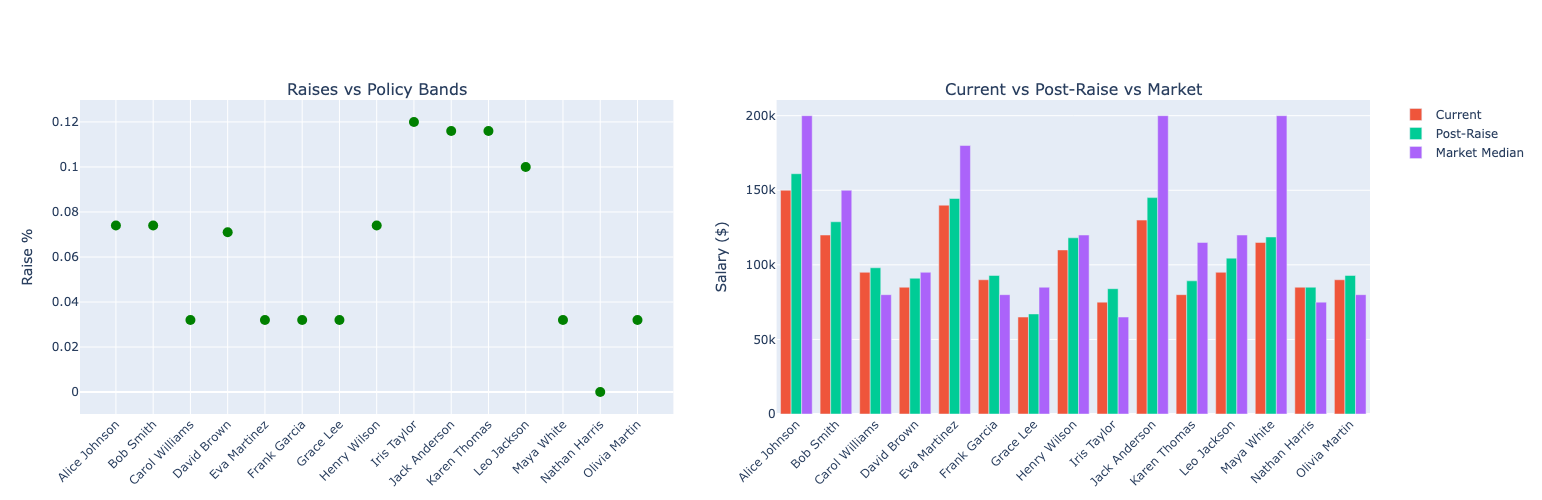

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Load both tables ---
pc = _constat_session.table("policy_comparison", pandas=True)
mc = _constat_session.table("market_comparison", pandas=True)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Raises vs Policy Bands", "Current vs Post-Raise vs Market"),
    horizontal_spacing=0.08,
)

# --- Left: Policy comparison scatter ---
pc_name = next((c for c in pc.columns if "name" in c.lower()), pc.columns[0])
pc_rating = next((c for c in pc.columns if "rating" in c.lower()), None)
pc_raise = next((c for c in pc.columns if "raise" in c.lower() and "pct" in c.lower()), None)
pc_min = next((c for c in pc.columns if "min" in c.lower()), None)
pc_max = next((c for c in pc.columns if "max" in c.lower()), None)
pc_flag = next((c for c in pc.columns if "range" in c.lower() or "flag" in c.lower()), None)

if all([pc_rating, pc_raise, pc_min, pc_max]):
    for rating in sorted(pc[pc_rating].unique()):
        sub = pc[pc[pc_rating] == rating]
        lo, hi = sub[pc_min].iloc[0], sub[pc_max].iloc[0]
        fig.add_hrect(
            y0=lo, y1=hi, fillcolor="green", opacity=0.08,
            annotation_text=f"Rating {rating}: {lo}-{hi}%",
            annotation_position="top left",
            row=1, col=1,
        )
    colors = ["green" if v else "red" for v in pc[pc_flag]] if pc_flag else "steelblue"
    fig.add_trace(go.Scatter(
        x=pc[pc_name], y=pc[pc_raise],
        mode="markers", marker=dict(size=10, color=colors),
        text=pc.apply(lambda r: f"Rating: {r[pc_rating]}, Raise: {r[pc_raise]:.1f}%", axis=1),
        hoverinfo="text+x", showlegend=False,
    ), row=1, col=1)
    fig.update_xaxes(tickangle=-45, row=1, col=1)
    fig.update_yaxes(title_text="Raise %", row=1, col=1)

# --- Right: Market comparison grouped bars ---
mc_name = next((c for c in mc.columns if "name" in c.lower()), mc.columns[0])
mc_curr = next((c for c in mc.columns if "current" in c.lower() and "sal" in c.lower()), None)
mc_new = next((c for c in mc.columns if "new" in c.lower() and "sal" in c.lower()), None)
mc_market = next((c for c in mc.columns if "market" in c.lower() and "median" in c.lower()), None)

if all([mc_curr, mc_new, mc_market]):
    fig.add_trace(go.Bar(name="Current", x=mc[mc_name], y=mc[mc_curr]), row=1, col=2)
    fig.add_trace(go.Bar(name="Post-Raise", x=mc[mc_name], y=mc[mc_new]), row=1, col=2)
    fig.add_trace(go.Bar(name="Market Median", x=mc[mc_name], y=mc[mc_market]), row=1, col=2)
    fig.update_xaxes(tickangle=-45, row=1, col=2)
    fig.update_yaxes(title_text="Salary ($)", row=1, col=2)

fig.update_layout(height=500, width=1200, barmode="group")
fig.show()

## Raise Distribution

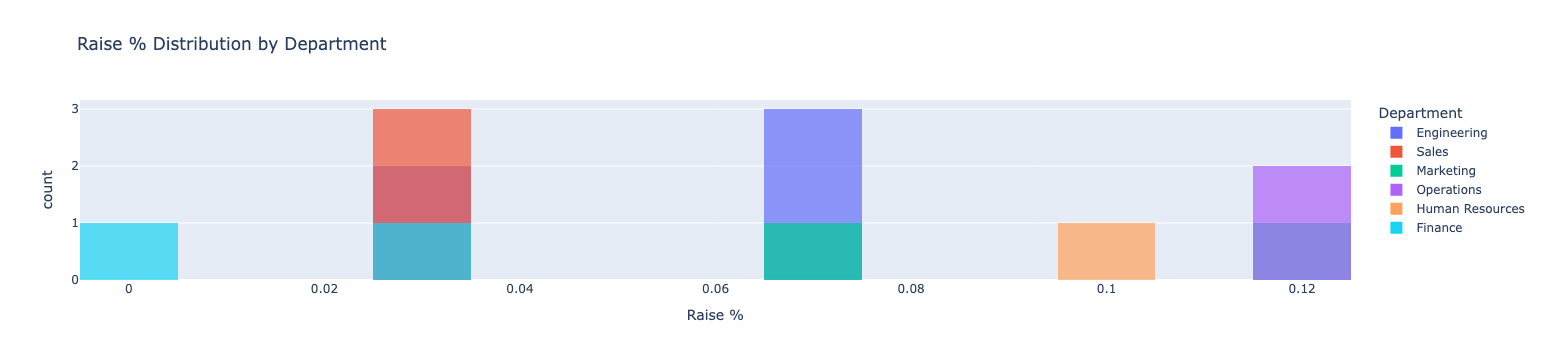

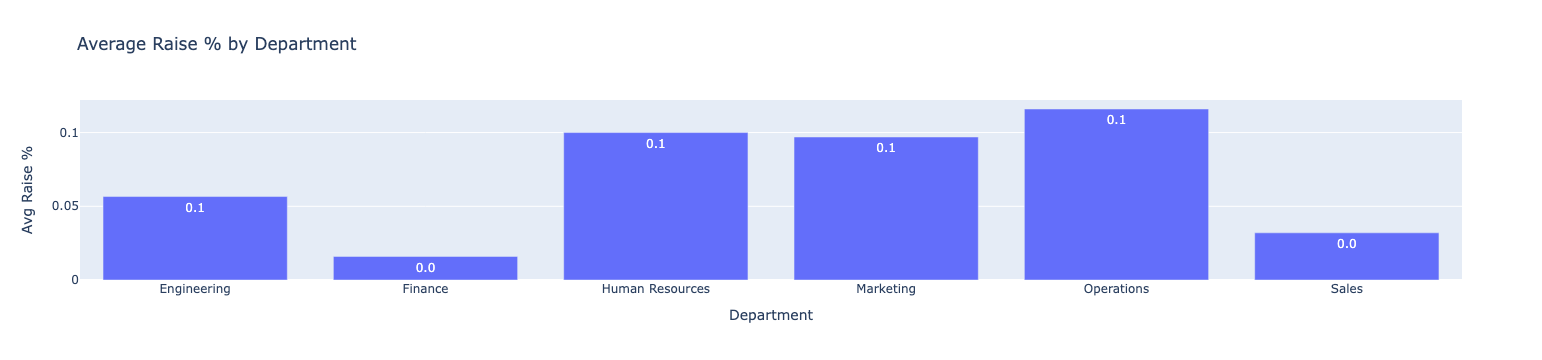

In [10]:
import plotly.express as px

df = _constat_session.table("raise_recommendations", pandas=True)

pct_col = next((c for c in df.columns if "raise" in c.lower() and "pct" in c.lower()), None)
dept_col = next((c for c in df.columns if "dept" in c.lower() or "department" in c.lower()), None)

if pct_col and dept_col:
    fig = px.histogram(
        df, x=pct_col, color=dept_col, nbins=15,
        title="Raise % Distribution by Department",
        labels={pct_col: "Raise %", dept_col: "Department"},
        barmode="overlay", opacity=0.7,
    )
    fig.show()

    avg = df.groupby(dept_col)[pct_col].mean().reset_index()
    fig2 = px.bar(
        avg, x=dept_col, y=pct_col,
        title="Average Raise % by Department",
        labels={pct_col: "Avg Raise %", dept_col: "Department"},
        text_auto=".1f",
    )
    fig2.show()
else:
    print(f"Expected columns not found. Available: {list(df.columns)}")

## Executive Summary

Generate a CFO-ready summary with budget impact and department breakdown.

In [11]:
%%constat auto include:md

Create an executive summary of the raise recommendations
for CFO approval. Include total budget impact, department
breakdown, and distribution by raise percentage tier.

**Answer:** Total raise budget impact is $96,055 across 15 employees, with significant variation in distribution across departments and performance tiers.

**Key Insight:** Operations and Marketing departments receive substantially higher average raises (11.6% and 9.7% respectively) compared to Finance and Sales (1.6% and 3.2%), suggesting targeted retention efforts in specific business areas. This imbalance warrants review to ensure equity and market competitiveness across all functions.

**Next Steps:**
1. What market data supports the 11.6% raise tier for Operations—are we addressing turnover risk or competitive positioning?
2. Should Finance's modest 1.6% average be reviewed to ensure retention of critical accounting/planning talent?
3. How does this year's distribution align with succession planning and strategic priorities for the next fiscal year?

## Employee Communications

Generate personalized raise announcement emails. The `published` flag
displays only starred (key result) tables.

In [12]:
%%constat auto published

Generate a personalized email communication for each employee
announcing their raise. Save to a table called employee_emails
with columns: employee_name, email_address, html_email_body

**Answer:** The `employee_emails` table has been generated with personalized raise announcements for all 15 employees, but a critical data quality issue requires immediate attention before distribution.

**Key Insight:** All 15 employees (100%) have raises assigned outside their performance rating policy ranges, with merit guidelines showing null rating values. This indicates either corrupted compensation policy data or misalignment between the rating system and policy guidelines—not a legitimate business decision. The raises themselves appear reasonable (3.2%-12% based on ratings 2-5), but proceeding without validating policy compliance risks legal and morale consequences.

**Next Steps:**
1. Validate the compensation policy document—are merit guidelines properly configured with rating labels?
2. Confirm whether raise recommendations were approved independently of policy, or if policy guidelines need updating?
3. Should email distribution be paused until policy alignment is verified?

In [13]:
# Preview email table and sample
df = _constat_session.table("employee_emails")
print(f"employee_emails: {len(df)} rows")
display(df.head(5))

row = df.to_pandas().iloc[0]
html_col = next((c for c in row.index if "html" in c.lower() and "body" in c.lower()), None)
if html_col:
    from IPython.display import HTML
    display(HTML(f"<h4>Sample email for {row.iloc[0]}:</h4>"))
    display(HTML(row[html_col]))

employee_emails: 15 rows


employee_name,email_address,html_email_body
"""Alice Johnson""","""alice.johnson@company.com""","""<html> <head> <sty…"
"""Bob Smith""","""bob.smith@company.com""","""<html> <head> <sty…"
"""Carol Williams""","""carol.williams@company.com""","""<html> <head> <sty…"
"""David Brown""","""david.brown@company.com""","""<html> <head> <sty…"
"""Olivia Martin""","""olivia.martin@company.com""","""<html> <head> <sty…"


## Export for Mail Merge

In [14]:
df = _constat_session.table("employee_emails", pandas=True)
df.to_csv("raise_emails.csv", index=False)
print(f"Exported {len(df)} emails to raise_emails.csv")

Exported 15 emails to raise_emails.csv
